# Fibroblast Cell State Exploration: Mucin vs. Fibrosis
This notebook explores the transcriptomic divergence of fibroblast states in Progressive Mucinous Histiocytosis (PMH). We will calculate module scores for mucin production and fibrotic ECM remodeling to determine if these represent sequential stages or distinct stromal populations.

In [1]:
library(Seurat)
library(ggplot2)
library(patchwork)
library(dplyr)

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”


Loading required package: SeuratObject

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘patchwork’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
out_dir <- "/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/plots/exploration"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

fib_obj <- readRDS("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/processed/fibroblast_detailed_annotated.rds")


In [2]:
seu_obj <- readRDS("/home/johan/output/skin_pmh/01_preprocessing/TN.combined_dim30.rds")
full_obj <- readRDS("/home/johan/output/skin_pmh/01_preprocessing/TN.combined_dim30_full.rds")


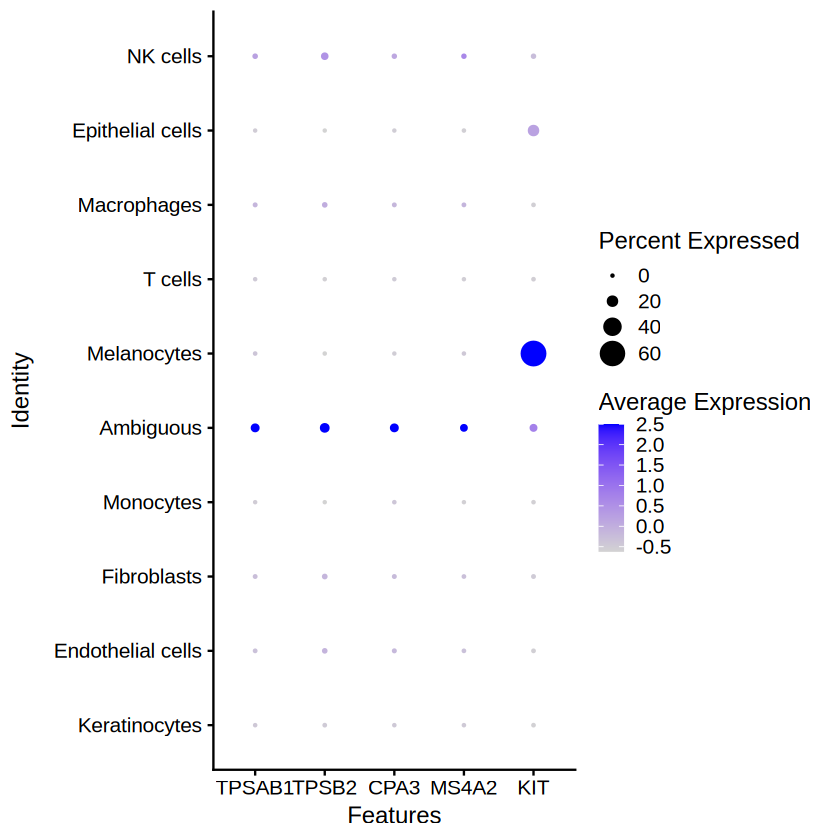

In [7]:
Idents(seu_obj) <- "cluster_label"   # or whatever holds "C14_Ambiguous"
DotPlot(seu_obj, features = c("TPSAB1","TPSB2","CPA3","MS4A2","KIT"))

In [21]:
seu_obj[[]]

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,seurat_clusters,pANN_0.25_0.005_227,DF.classifications_0.25_0.005_227,⋯,S.Score,G2M.Score,Phase,batch,SCT_snn_res.0.05,SCT_snn_res.0.1,SCT_snn_res.0.2,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.6
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<fct>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<chr>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
HTY2901_AAACAAGCACAGGCTG-1,2901,1708,1170,0.00000000,1360,1145,0,1,0.19047619,Singlet,⋯,-0.037940805,-0.108571436,G1,HTY2901,2,2,1,1,1,0
HTY2901_AAACAAGCATCAGGTA-1,2901,1465,1069,0.00000000,1316,1049,0,1,0.33333333,Singlet,⋯,-0.084886192,-0.045456683,G1,HTY2901,2,2,1,1,1,0
HTY2901_AAACCAATCAGTTTAC-1,2901,3569,2044,0.00000000,907,658,15,0,0.14285714,Singlet,⋯,-0.045379139,0.020380205,G2M,HTY2901,1,0,0,0,11,12
HTY2901_AAACCAGGTTCCAGCA-1,2901,950,795,0.42105263,919,775,1,4,0.38095238,Singlet,⋯,-0.073043222,-0.093011597,G1,HTY2901,3,4,4,3,3,3
HTY2901_AAACCGGTCCTGGTTA-1,2901,583,510,2.74442539,640,491,1,4,0.28571429,Singlet,⋯,0.032897123,0.002663686,S,HTY2901,3,4,4,3,3,3
HTY2901_AAACGTTCATATTTCG-1,2901,2130,1482,0.00000000,1634,1438,2,0,0.33333333,Singlet,⋯,-0.081600144,-0.136571534,G1,HTY2901,1,0,0,0,0,2
HTY2901_AAACTGGGTGATTACC-1,2901,910,725,0.32967033,859,682,3,5,0.04761905,Singlet,⋯,0.001967457,-0.036669232,S,HTY2901,0,1,5,4,4,4
HTY2901_AAACTGTCAACCTGTT-1,2901,2343,1520,0.00000000,1656,1416,2,0,0.14285714,Singlet,⋯,0.018122599,-0.076535762,S,HTY2901,1,0,0,0,0,2
HTY2901_AAACTGTCACGGTACG-1,2901,925,769,0.54054054,885,745,22,16,0.23809524,Singlet,⋯,-0.091490941,-0.022943110,G1,HTY2901,6,6,16,16,17,18


### 1. Define Signatures & Calculate Module Scores
We define two specific gene signatures based on PMH pathology:
* **Mucin Signature**: Hyaluronan synthases, structural mesh, and degradation machinery.
* **Fibrosis Signature**: Core collagens and pathogenic myofibroblast markers (e.g., POSTN, ACTA2).

In [ ]:
# Define signatures
mucin_genes <- c("HAS2", "HAS1", "HAS3", "VCAN", "FN1", "CEMIP", "HYAL1", "HYAL2", "CTGF", "TGFBI")
fibro_genes <- c("COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL6A1", "FN1", "SPARC", "CTGF", "POSTN", "ACTA2", "TAGLN", "LOX", "LOXL2")
# Safely intersect with available genes in the dataset
valid_mucin <- intersect(mucin_genes, rownames(fib_obj))
valid_fibro <- intersect(fibro_genes, rownames(fib_obj))

# Calculate module scores (Seurat appends "1" to the name -> Mucin_Score1)
fib_obj <- AddModuleScore(fib_obj, features = list(valid_mucin), name = "Mucin_Score")
fib_obj <- AddModuleScore(fib_obj, features = list(valid_fibro), name = "Fibrosis_Score")

# Ensure our detailed labels are the active identity
Idents(fib_obj) <- "Detailed_Label"


print("Scoring Complete. Metadata columns 'Mucin_Score1' and 'Fibrosis_Score1' added.")

[1] "Scoring Complete. Metadata columns 'Mucin_Score1' and 'Fibrosis_Score1' added."


### 2. Spatial Mapping (UMAP)
Visualize where the mucin-producing and fibrotic cells physically sit on the UMAP. The `blend = TRUE` argument will highlight areas of co-expression.

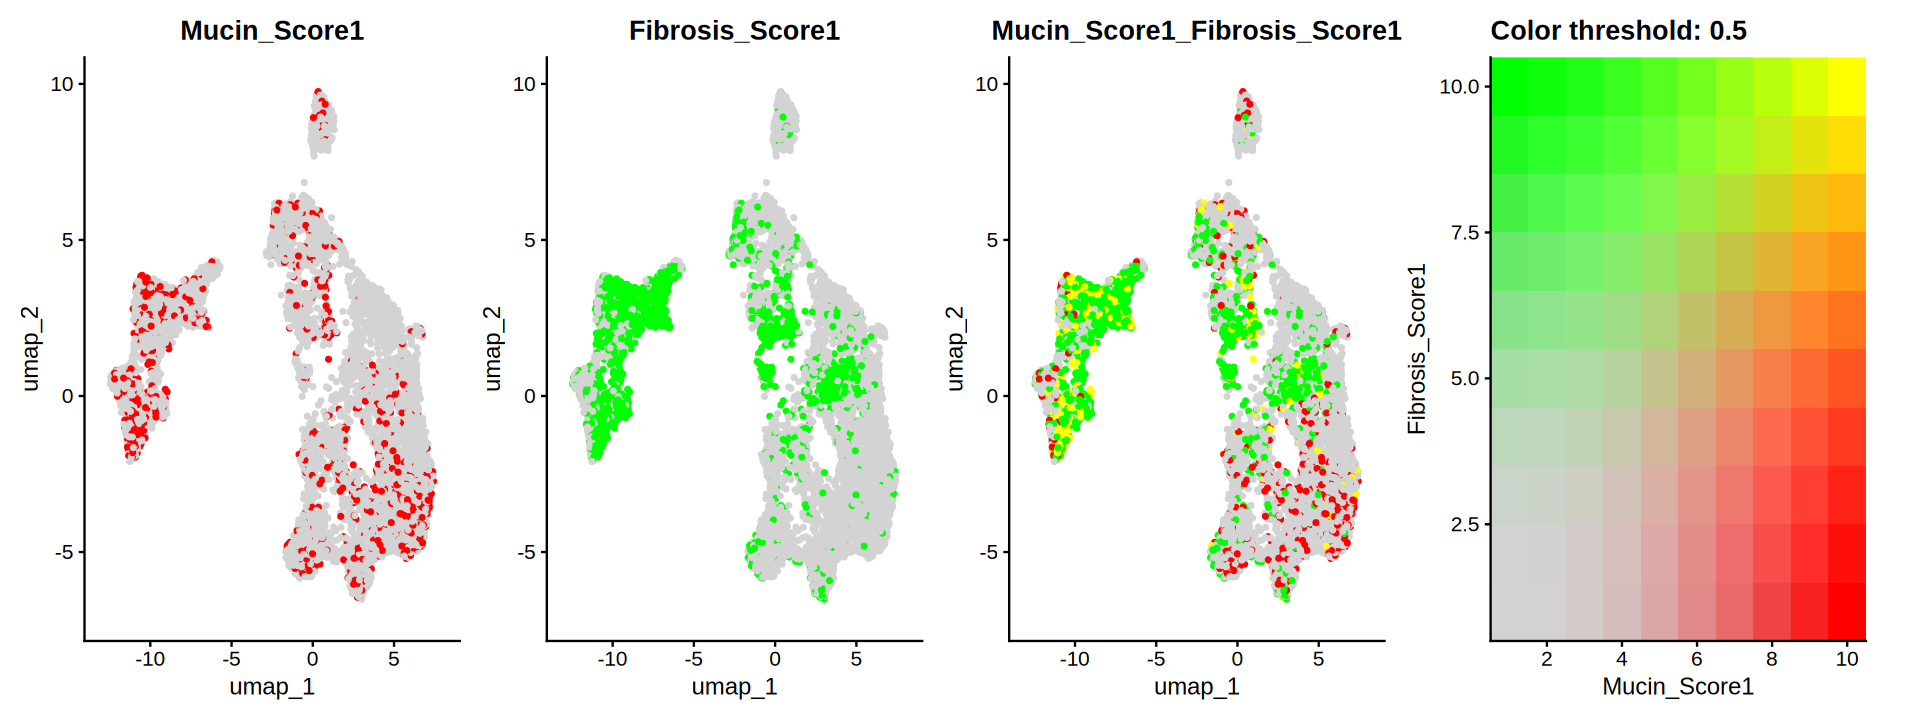

In [ ]:
# Configure plot size for Jupyter inline viewing
options(repr.plot.width = 16, repr.plot.height = 6)

p_umap <- FeaturePlot(fib_obj, 
                      features = c("Mucin_Score1", "Fibrosis_Score1"), 
                      blend = TRUE, 
                      pt.size = 0.8)

# Display inline
p_umap

### 3. Expression by Fibroblast Subtype
Which specific fibroblast subtypes are driving these signatures?

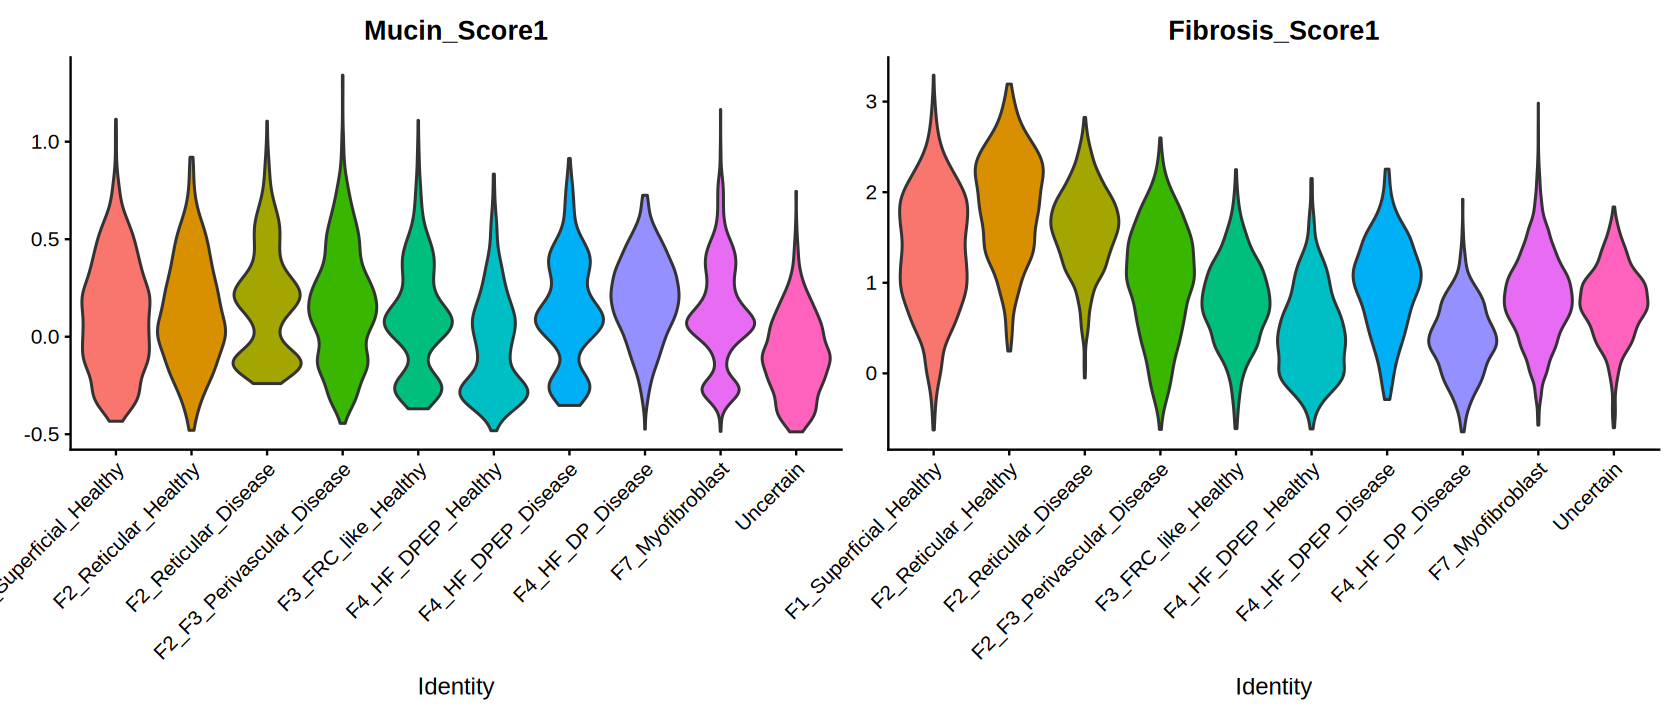

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 6)

p_vln <- VlnPlot(fib_obj, 
                 features = c("Mucin_Score1", "Fibrosis_Score1"), 
                 group.by = "Detailed_Label", 
                 pt.size = 0) + 
         theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Display inline
p_vln

### 4. Disease Progression (Acute vs. Chronic)
If your metadata contains a `Detailed_Condition` column (Healthy vs. Acute vs. Chronic), this will split the violins to show how the gene signatures evolve over time.
*(Note: If you only have "Healthy" and "PMH" in your `Condition` column, change `split.by` to "Condition")*

Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”


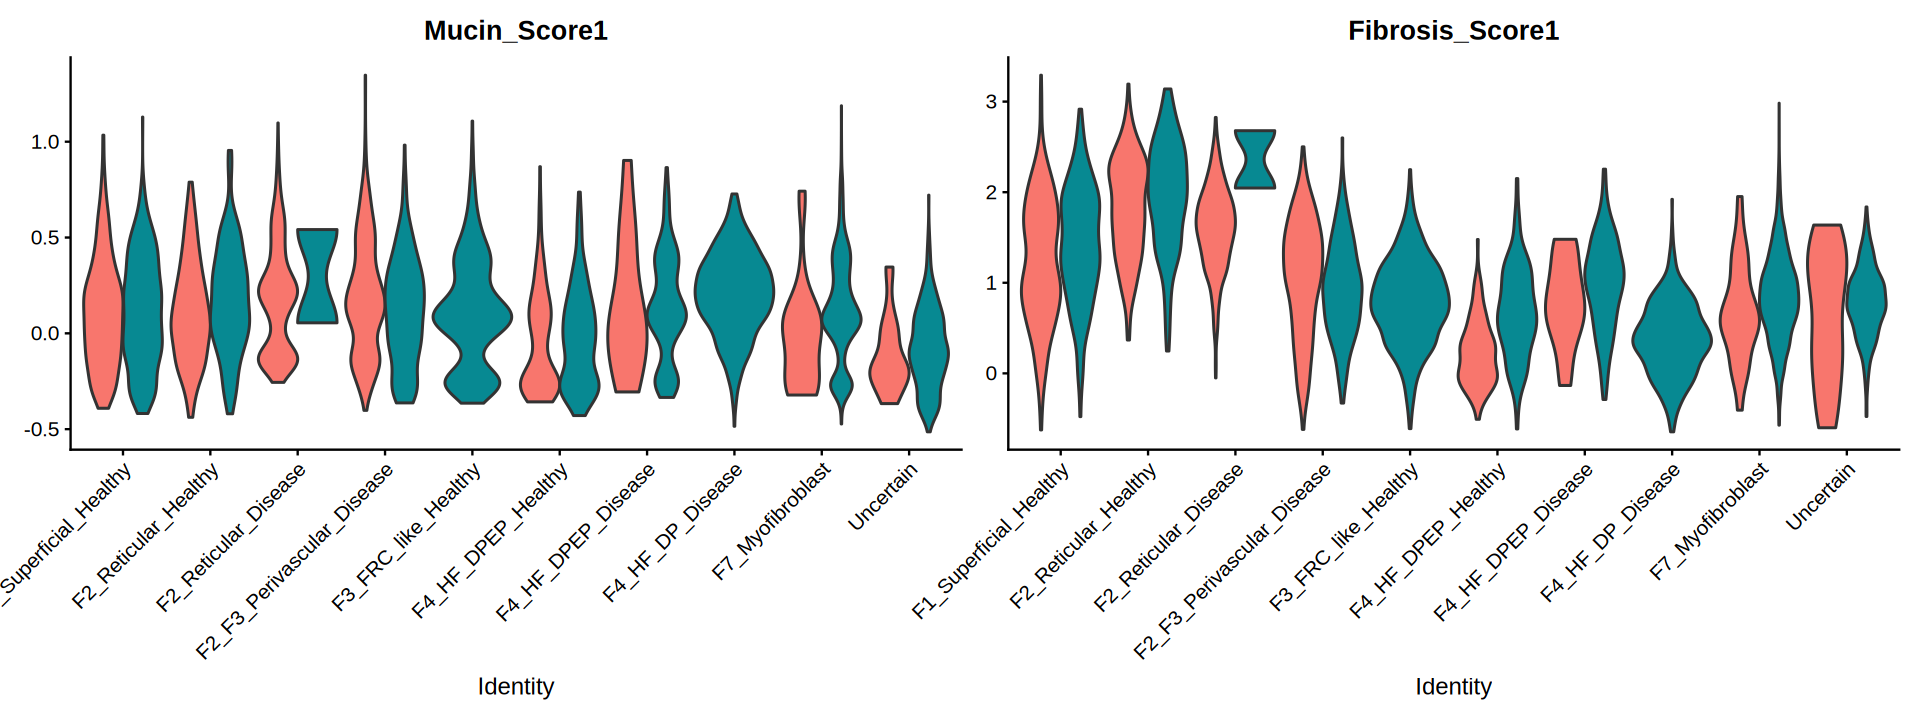

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 6)

# Swap "Condition" for "Detailed_Condition" if you have Acute/Chronic defined in your metadata
p_split <- VlnPlot(fib_obj, 
                   features = c("Mucin_Score1", "Fibrosis_Score1"), 
                   group.by = "Detailed_Label", 
                   split.by = "Condition",  
                   pt.size = 0) +
           theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Display inline
p_split

### 5. Cell State Dynamics (Scatter Plot)
Are Mucin-high and Fibrosis-high states mutually exclusive (L-shape), or are they a continuous transitional state (diagonal)?

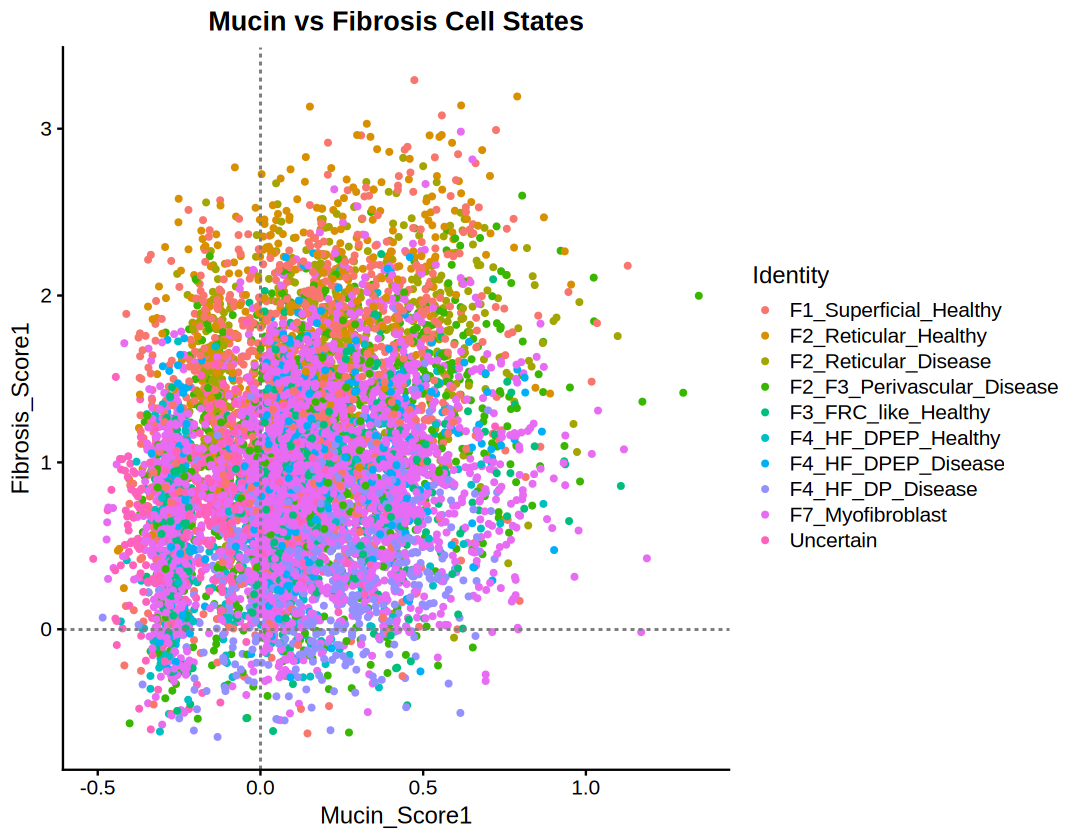

In [ ]:
options(repr.plot.width = 9, repr.plot.height = 7)

p_scatter <- FeatureScatter(fib_obj, 
                            feature1 = "Mucin_Score1", 
                            feature2 = "Fibrosis_Score1", 
                            group.by = "Detailed_Label") +
             geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") + 
             geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
             ggtitle("Mucin vs Fibrosis Cell States")

# Display inline
p_scatter

### 6. Mucin Dynamics: Synthesis vs. Degradation (HAS1 & HYAL2)
Progressive Mucinous Histiocytosis (PMH) is characterized by an over-accumulation of mucin in the dermis. To understand why this happens, we must look at the balance of two opposing forces:
* **Synthesis (`HAS1`)**: Hyaluronan synthase 1, responsible for spinning out new mucin.
* **Degradation (`HYAL2`)**: Hyaluronidase 2, responsible for breaking down excess mucin.

We will split the UMAP by `Condition` (Healthy vs. PMH) to see how this balance shifts during the disease state.

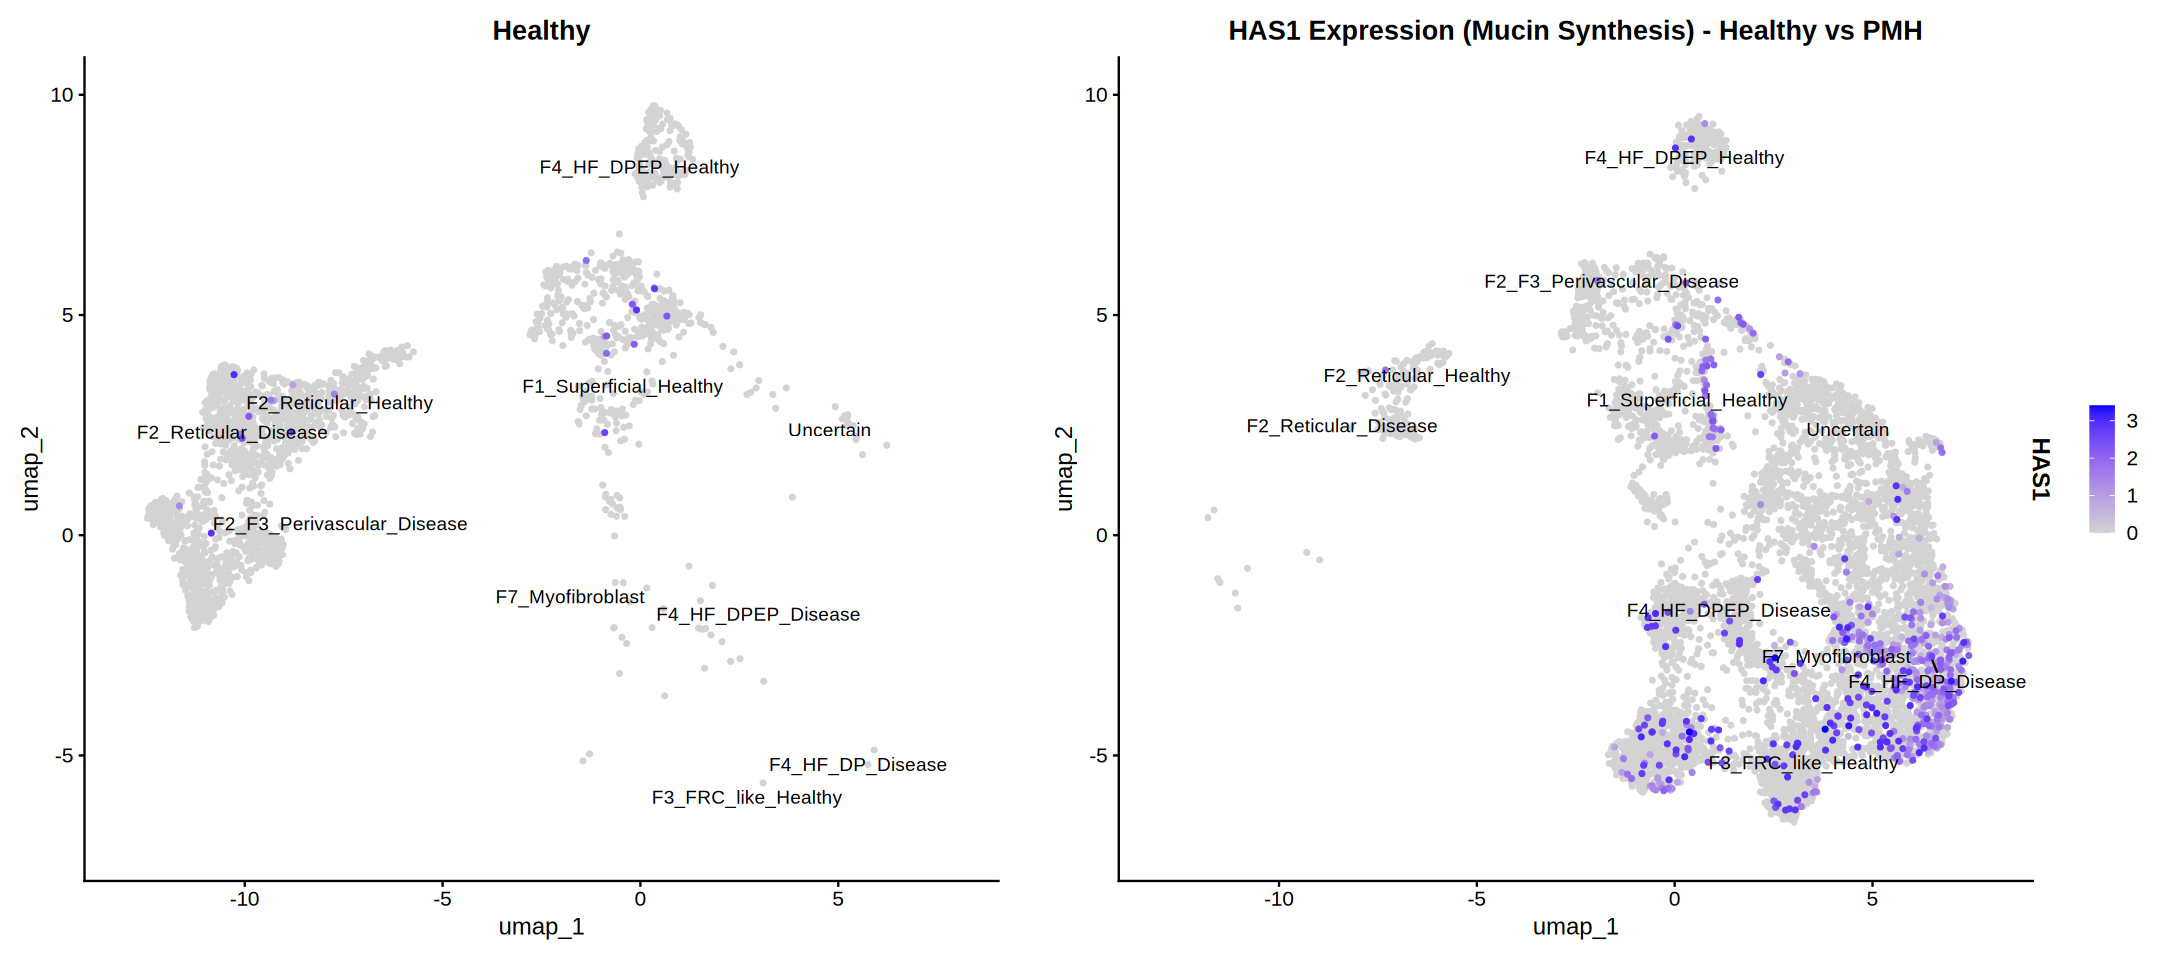

In [ ]:
# Configure plot size for side-by-side split UMAP
options(repr.plot.width = 18, repr.plot.height = 8)

# Check if HAS1 is in the dataset
if ("HAS1" %in% rownames(seu_obj)) {
    p_has1 <- FeaturePlot(seu_obj, 
                          features = "HAS1", 
                          split.by = "Condition",  # Split Left (Healthy) / Right (PMH)
                          label = TRUE, 
                          repel = TRUE, 
                          pt.size = 0.8,
                          order = TRUE) +          # 'order = TRUE' forces expressing cells to the front layer
              theme(legend.position = "right") +
              ggtitle("HAS1 Expression (Mucin Synthesis) - Healthy vs PMH")
    
    print(p_has1)
} else {
    print("HAS1 not found in the current assay.")
}

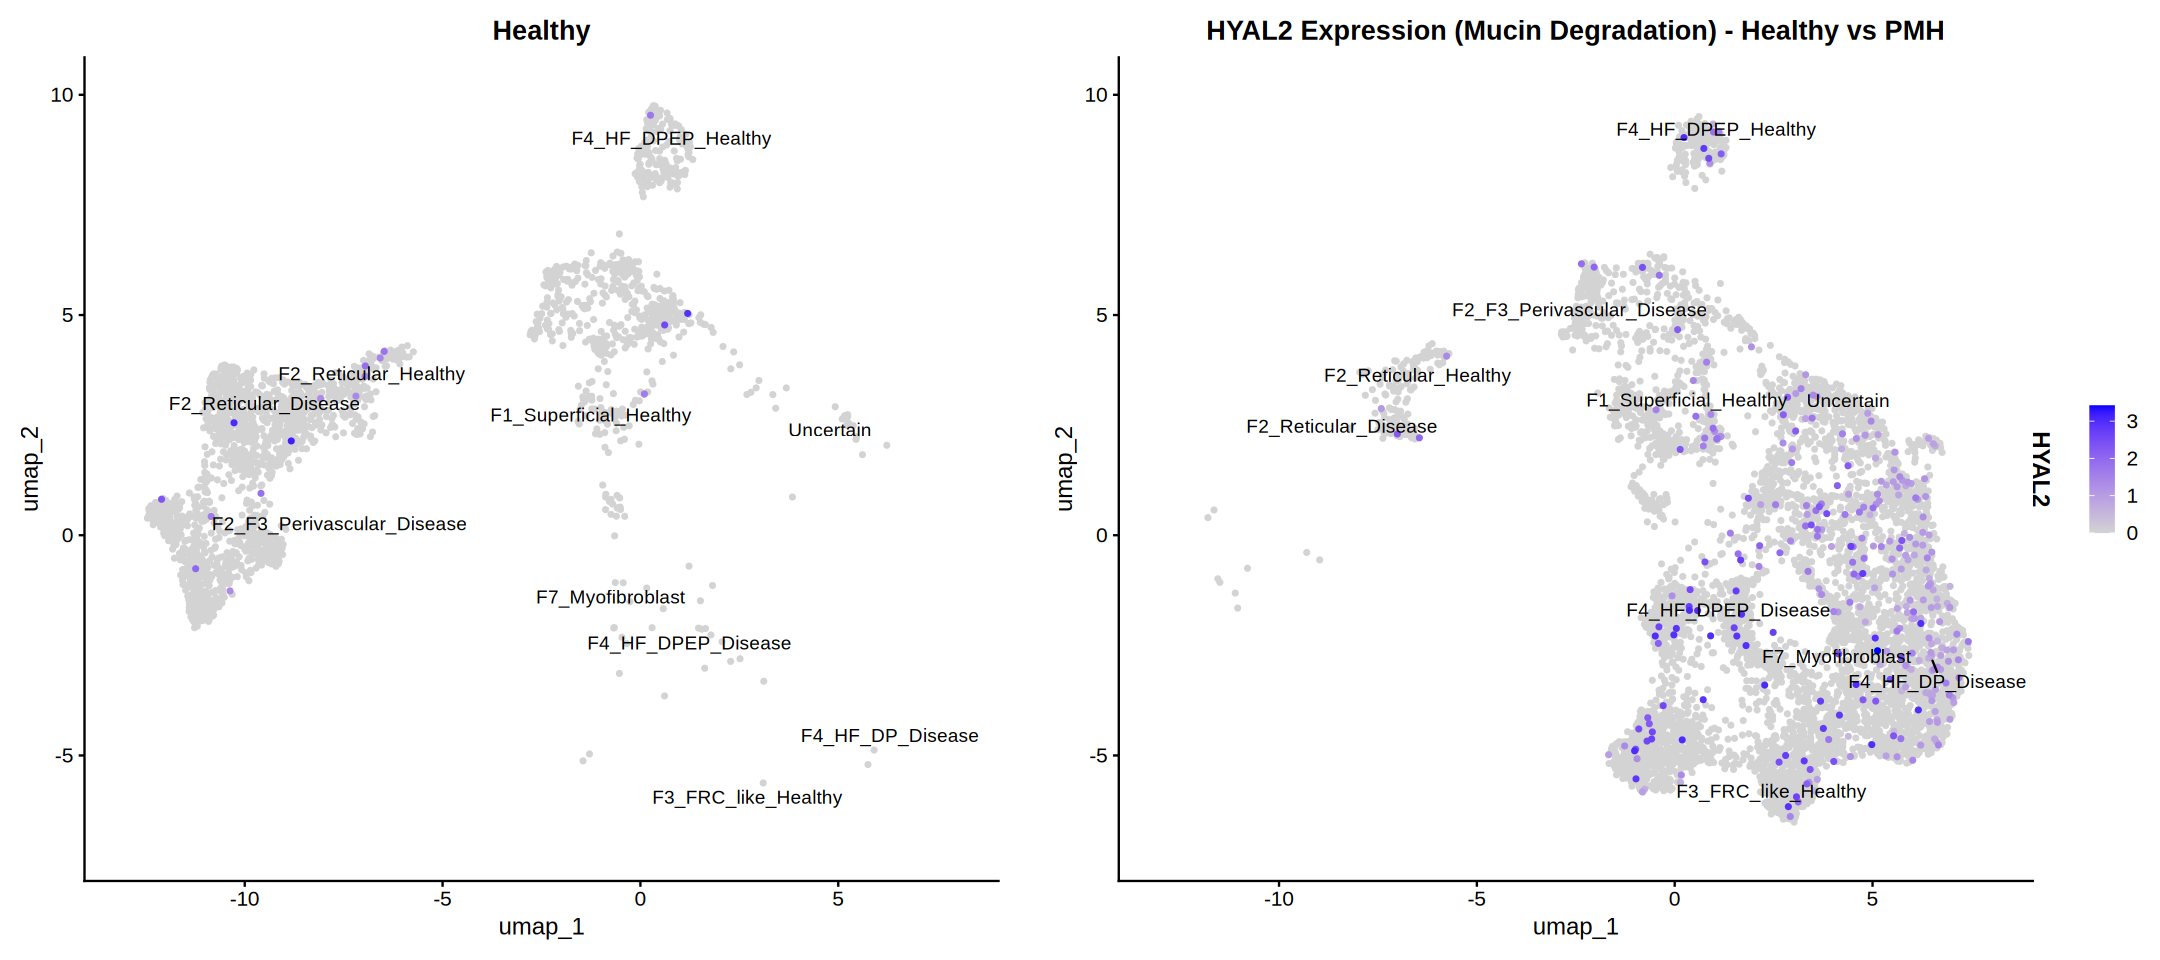

In [ ]:
# Configure plot size for side-by-side split UMAP
options(repr.plot.width = 18, repr.plot.height = 8)

# Check if HYAL2 is in the dataset
if ("HYAL2" %in% rownames(seu_obj)) {
    p_hyal2 <- FeaturePlot(seu_obj, 
                           features = "HYAL2", 
                           split.by = "Condition",  # Split Left (Healthy) / Right (PMH)
                           label = TRUE, 
                           repel = TRUE, 
                           pt.size = 0.8,
                           order = TRUE) +
               theme(legend.position = "right") +
               ggtitle("HYAL2 Expression (Mucin Degradation) - Healthy vs PMH")
    
    print(p_hyal2)
} else {
    print("HYAL2 not found in the current assay.")
}

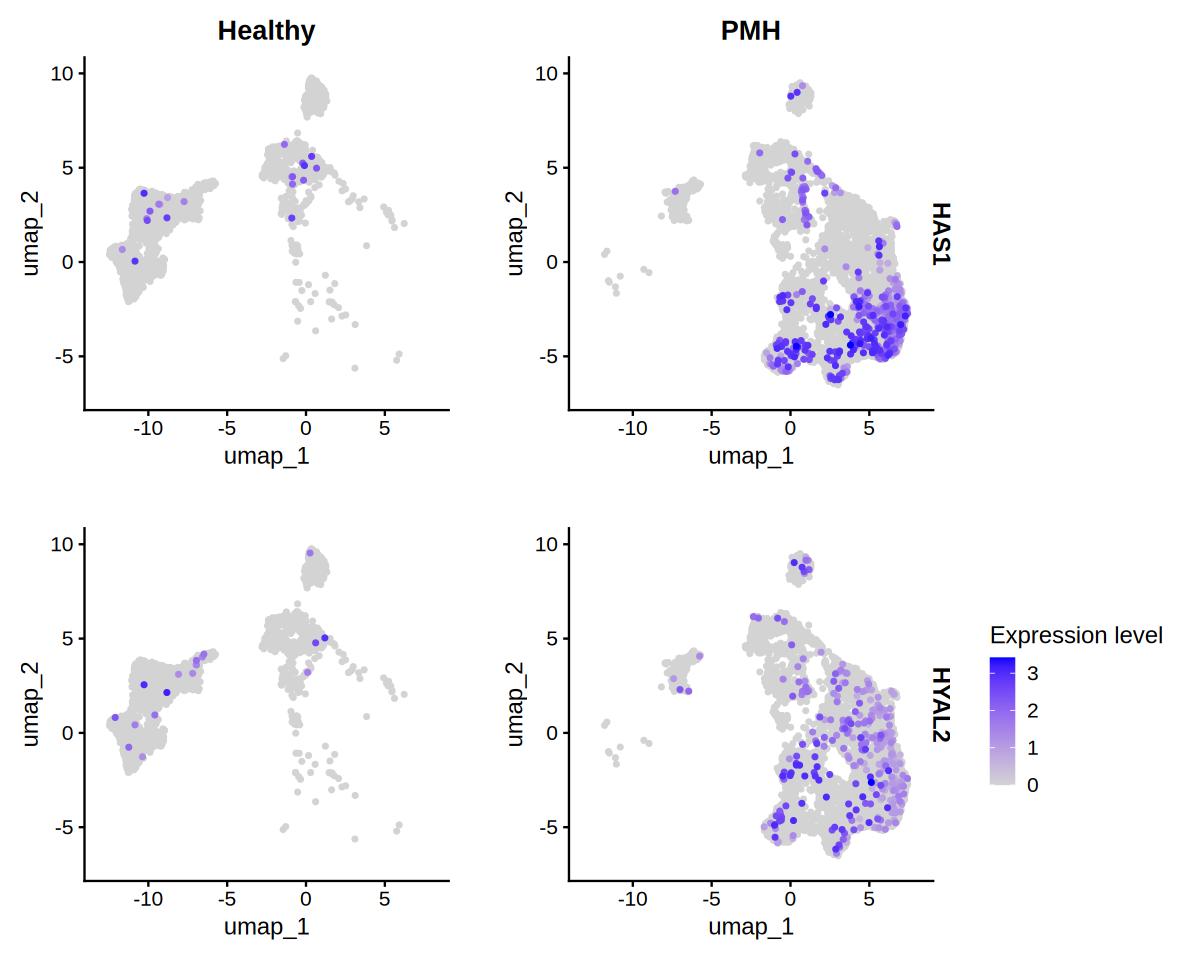

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)

FeaturePlot(fib_obj,
            features = c("HAS1", "HYAL2"),
            split.by = "Condition",
            pt.size = 0.8,
            order = TRUE,
            combine = TRUE
            ) +
  theme(
    legend.position = "right",
    legend.justification = "center"
  ) +
  labs(color = "Expression level")

# Global Analysis


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
4694 4033 3586 2835 2426 2424 1749 1609 1484 1070 1024  566  410  366  324  292 
  16 
 102 

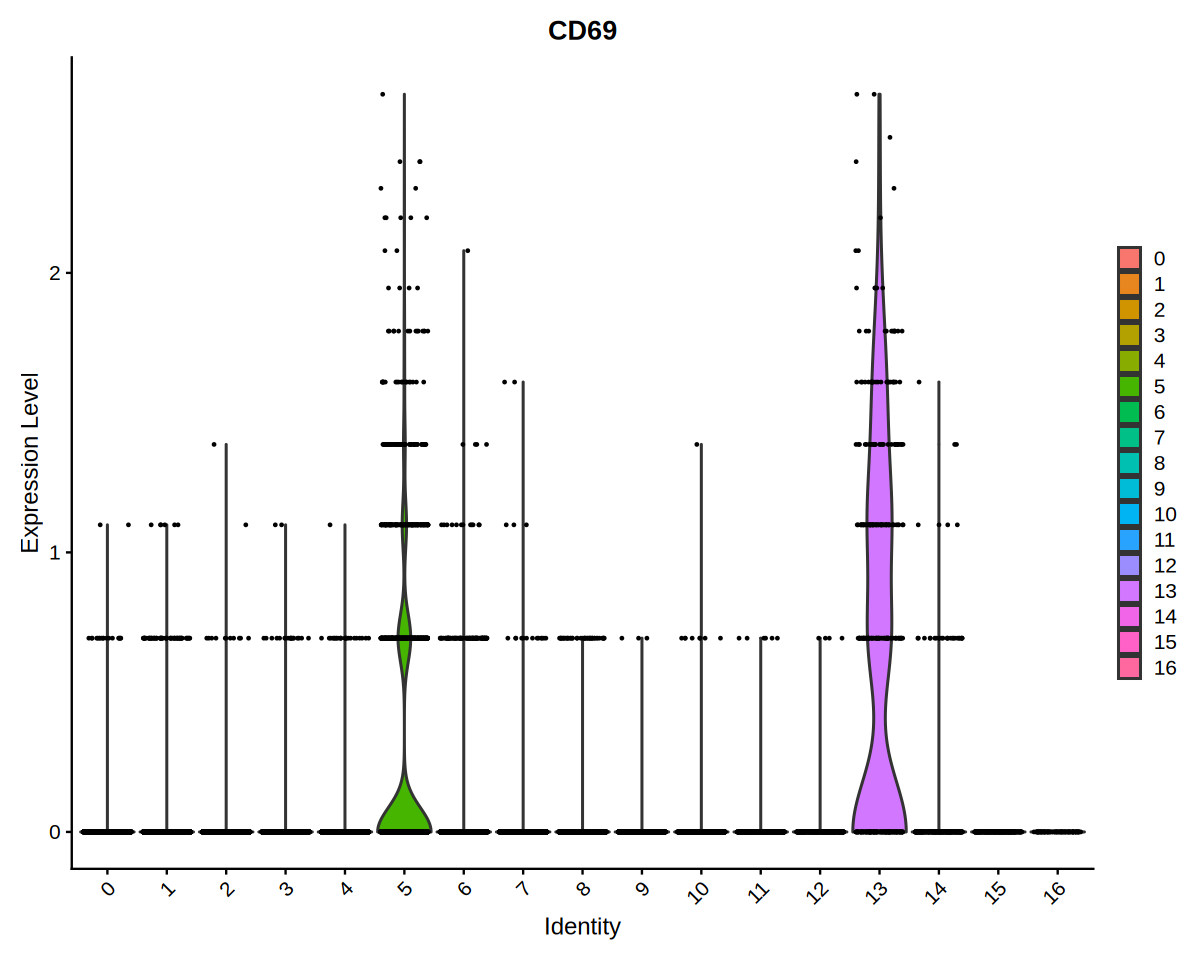

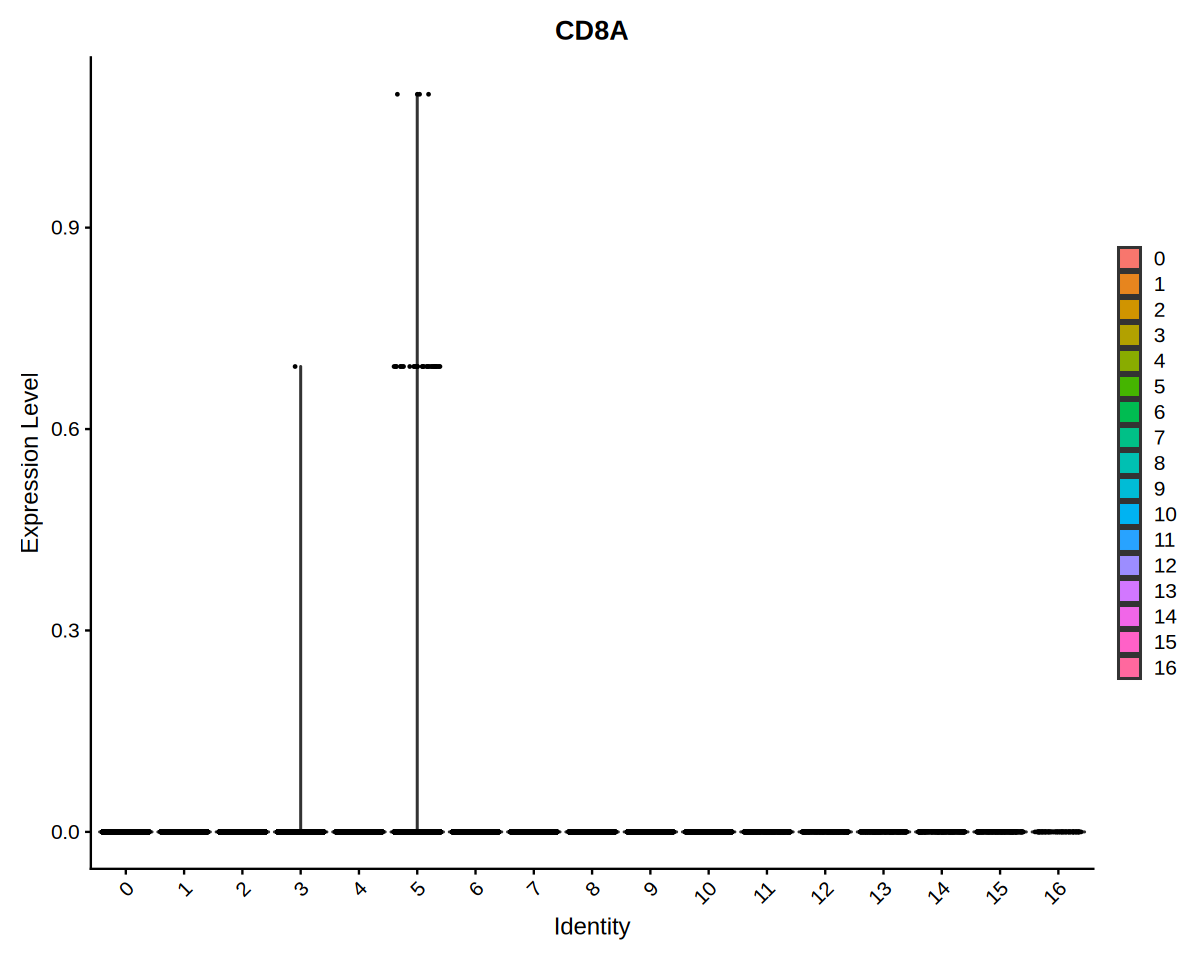

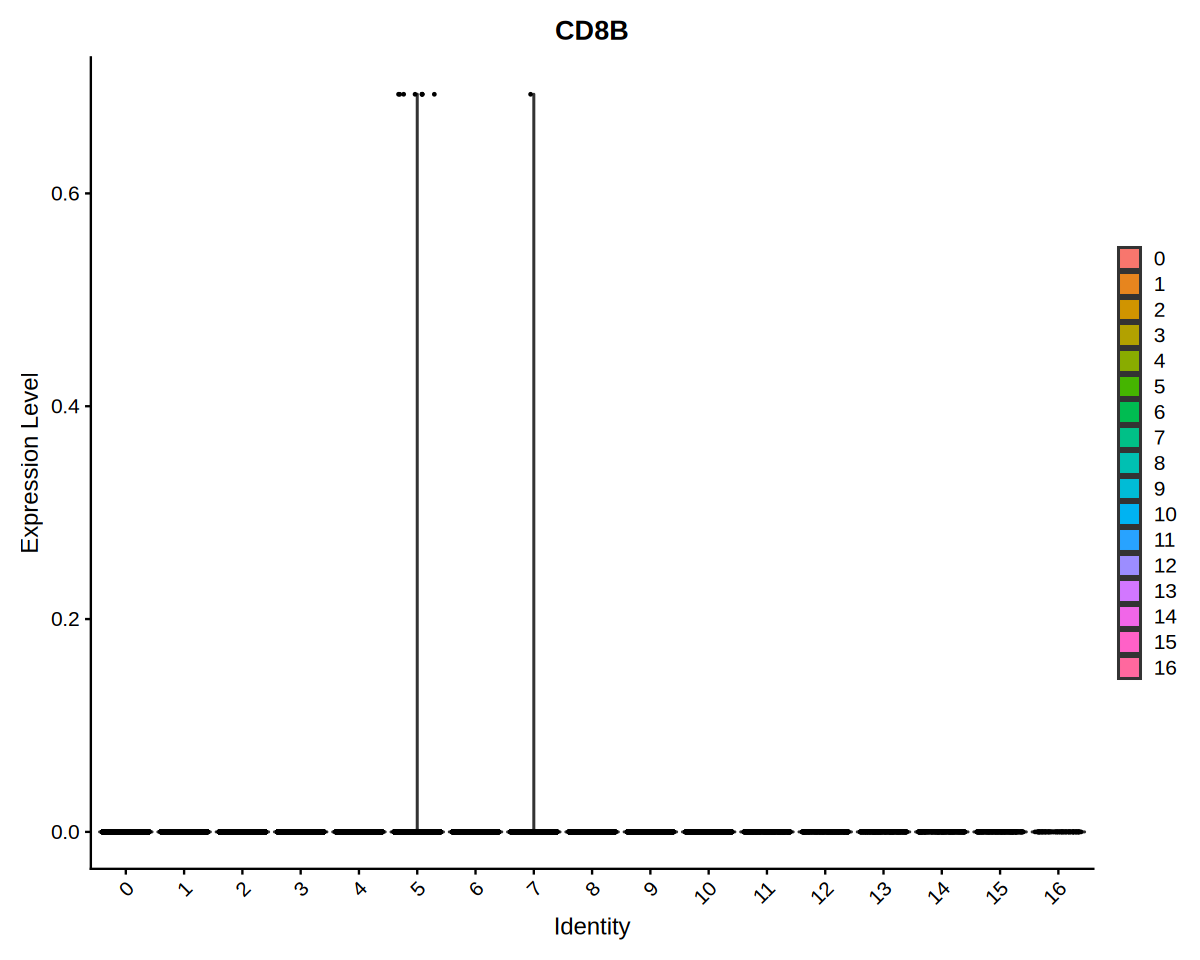

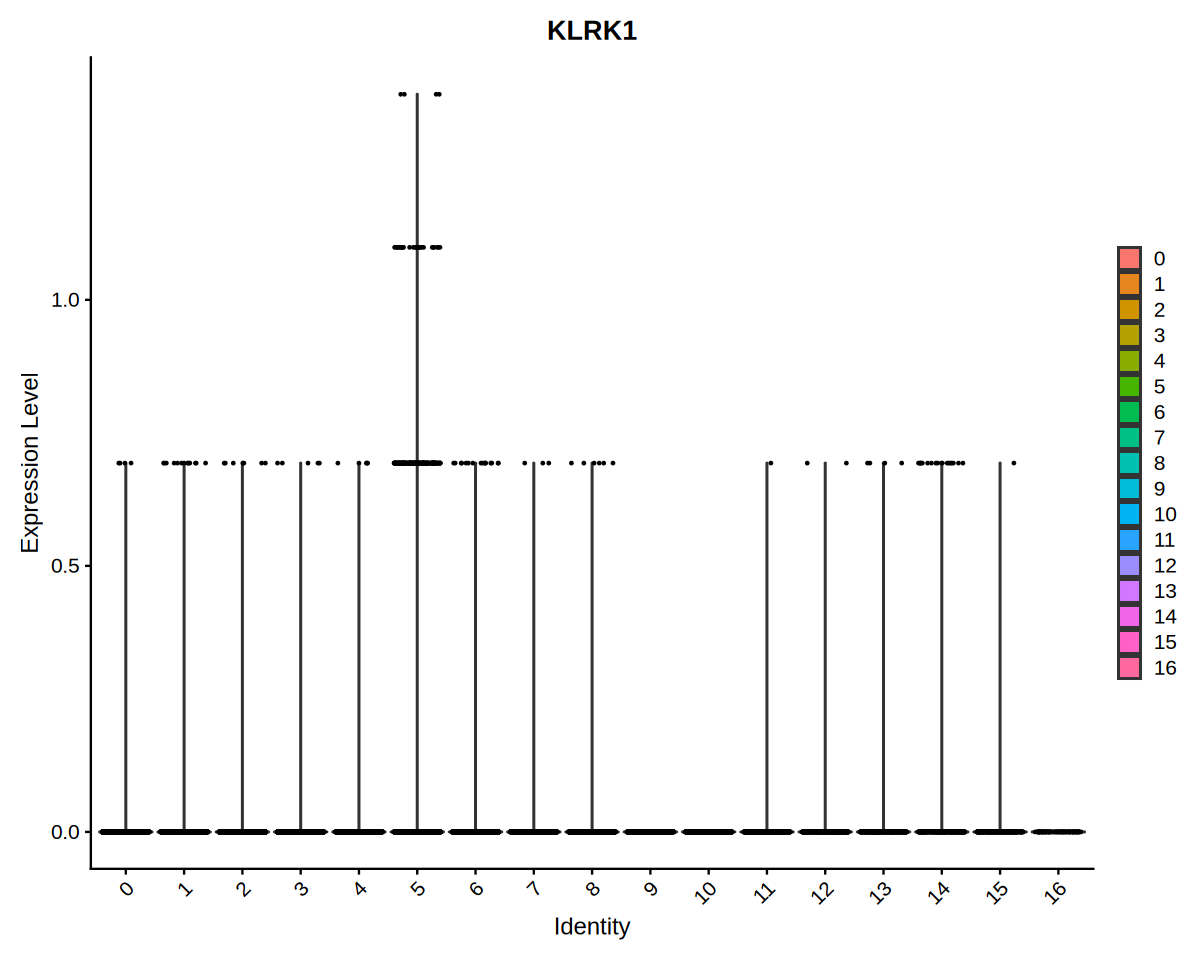

In [ ]:
global_obj <- readRDS("/home/johan/johan/output/skin_pmh_harmony_sctransform2/TN.combined_dim30.rds")
table(Idents(global_obj))
VlnPlot(global_obj, features = "CD69")
VlnPlot(global_obj, features = "CD8A")
VlnPlot(global_obj, features = "CD8B")
VlnPlot(global_obj, features = "CD103")


In [ ]:
grep("CD10", rownames(global_obj), value = TRUE)

[1] "CD101"  "PDCD10" "CD109"

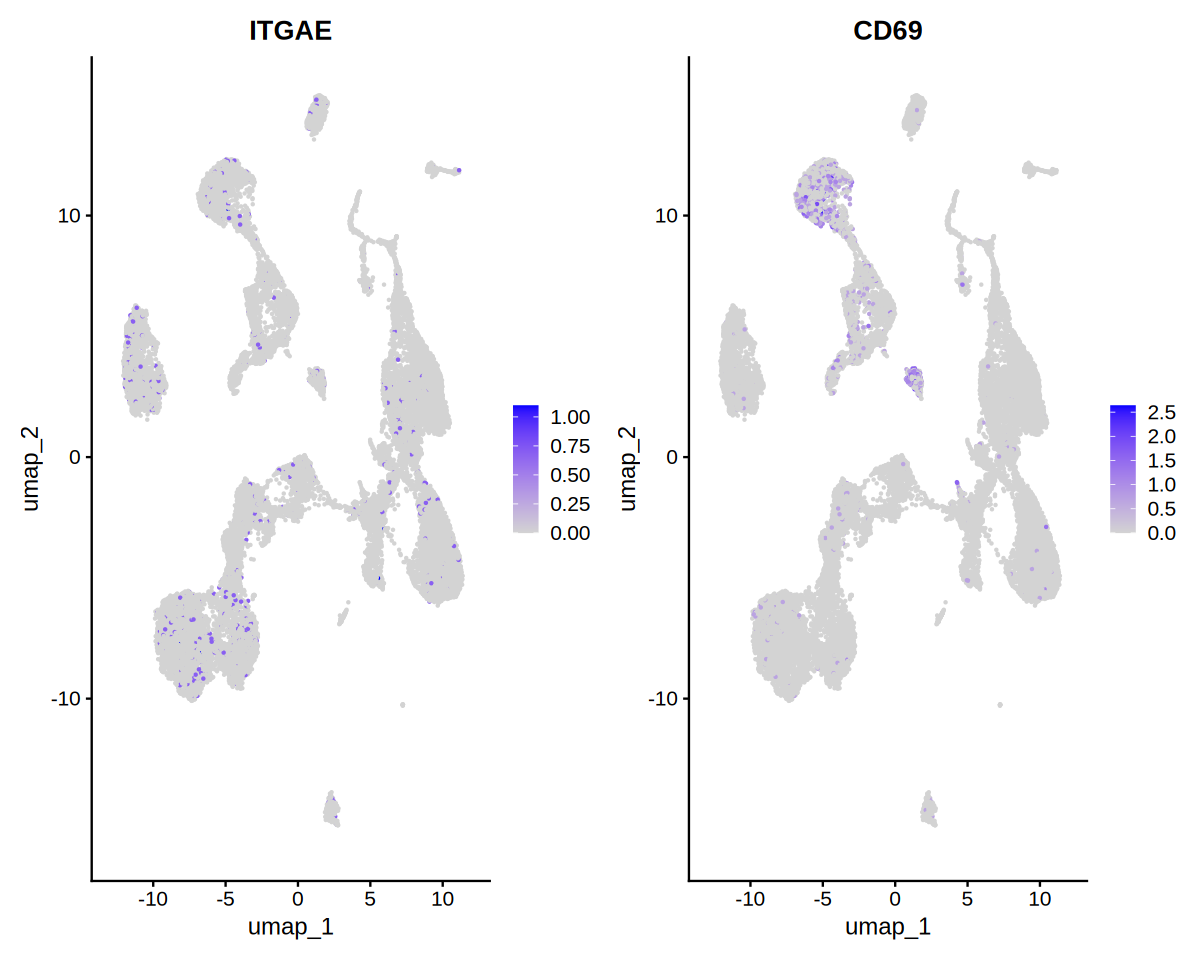

In [ ]:
FeaturePlot(global_obj, c("ITGAE", "CD69"))

In [ ]:
NK.genes   <- list(c("NKG7","GNLY","PRF1","GZMB","CTSW","FCGR3A","NCR1","KLRD1"))
Treg.genes <- list(c("FOXP3","IL2RA","CTLA4","TIGIT","TNFRSF18","CCR8","IKZF2"))
Th1.genes  <- list(c("TBX21","IFNG","IL12RB2","CXCR3","STAT1","STAT4"))
Th2.genes  <- list(c("GATA3","CCR4","IL4R","IL13","PTGDR2","MAF","BATF"))
Th17.genes <- list(c("RORC","IL17A","IL17F","CCR6","IL23R","STAT3","KLRB1"))

In [ ]:
global_obj <- AddModuleScore(global_obj, NK.genes, name = "NKScore")
global_obj <- AddModuleScore(global_obj, Treg.genes, name = "TregScore")
global_obj <- AddModuleScore(global_obj, Th1.genes, name = "Th1Score")
global_obj <- AddModuleScore(global_obj, Th2.genes, name = "Th2Score")
global_obj <- AddModuleScore(global_obj, Th17.genes, name = "Th17Score")

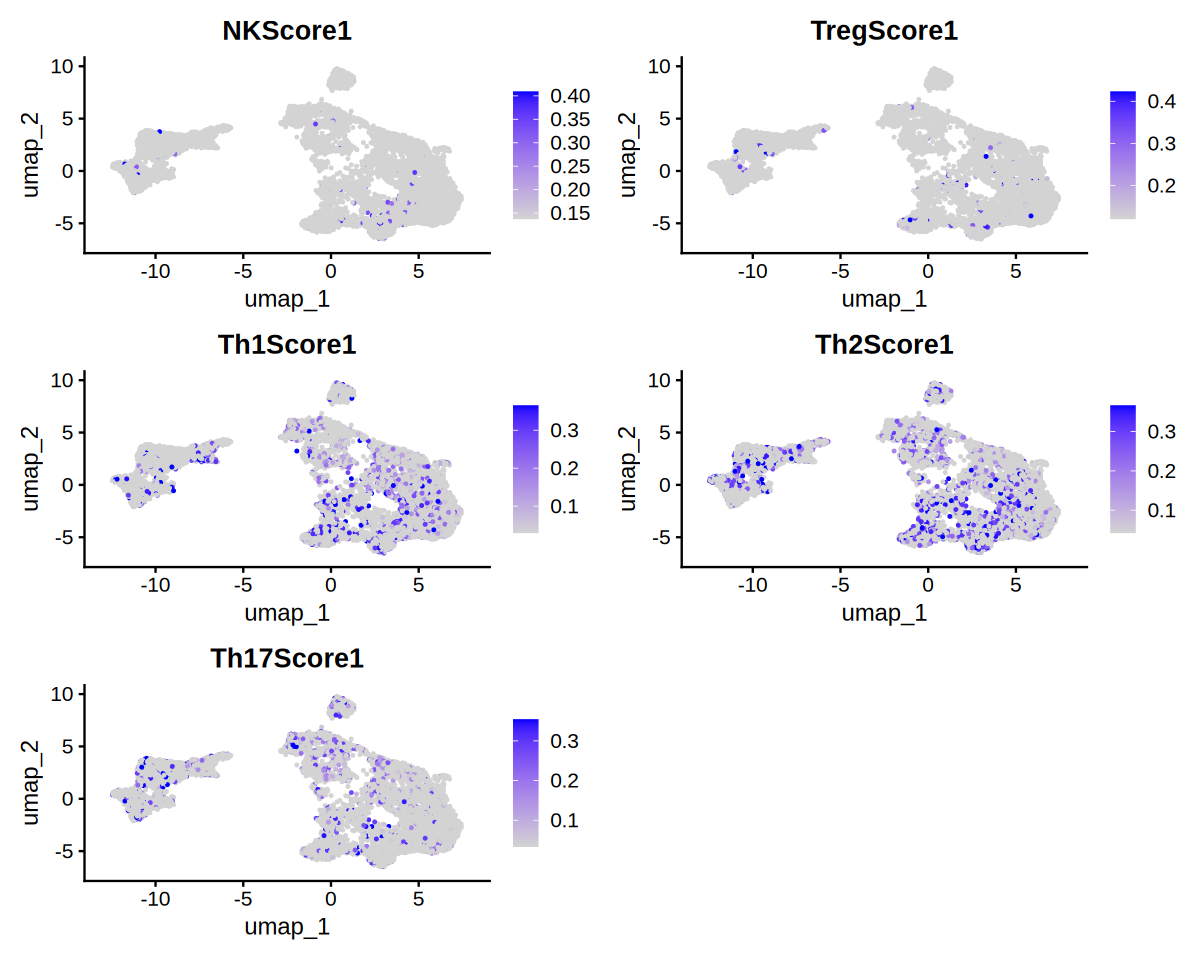

In [ ]:
FeaturePlot(global_obj, features = c(
  "NKScore1",
  "TregScore1",
  "Th1Score1",
  "Th2Score1",
  "Th17Score1"
),min.cutoff = "q10",
  max.cutoff = "q90")

In [ ]:
colnames(global_obj@meta.data)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_SCT"                        "nFeature_SCT"                     
 [7] "SCT_snn_res.0.8"                   "seurat_clusters"                  
 [9] "pANN_0.25_0.005_226"               "DF.classifications_0.25_0.005_226"
[11] "orig.ident1"                       "orig.ident2"                      
[13] "pANN_0.25_0.01_100"                "DF.classifications_0.25_0.01_100" 
[15] "pANN_0.25_0.005_591"               "DF.classifications_0.25_0.005_591"
[17] "pANN_0.25_0.005_182"               "DF.classifications_0.25_0.005_182"
[19] "pANN_0.25_0.23_208"                "DF.classifications_0.25_0.23_208" 
[21] "pANN_0.25_0.005_522"               "DF.classifications_0.25_0.005_522"
[23] "pANN_0.25_0.01_467"                "DF.classifications_0.25_0.01_467" 
[25] "S.Score"                           "G2M.Score"                        
[27] "Phase"                             "batch"                            
[29] "SCT_snn_res.0.05"                  "SCT_snn_res.0.1"                  
[31] "SCT_snn_res.0.2"                   "SCT_snn_res.0.3"                  
[33] "SCT_snn_res.0.4"                   "SCT_snn_res.0.6"                  
[35] "global_cluster"                    "SCT_snn_res.1"                    
[37] "SCT_snn_res.1.2"                   "Detailed_Condition"               
[39] "Condition"                         "ProgScore_1"                      
[41] "ProgScore_2"                       "ProgScore_3"                      
[43] "ProgScore_4"                       "ProgScore_5"                      
[45] "ProgScore_6"                       "ProgScore_7"                      
[47] "ProgScore_8"                       "ProgScore_9"                      
[49] "ProgScore_10"                      "ProgScore_11"                     
[51] "ProgScore_12"                      "ProgScore_13"                     
[53] "ProgScore_14"                      "ProgScore_15"                     
[55] "ProgScore_16"                      "ProgScore_17"                     
[57] "ProgScore_18"                      "ProgScore_19"                     
[59] "ProgScore_20"                      "ProgScore_21"                     
[61] "ProgScore_22"                      "Detailed_Label"                   
[63] "Macro_Lineage"                     "NKScore1"                         
[65] "TregScore1"                        "Th1Score1"                        
[67] "Th2Score1"                         "Th17Score1"                       
[69] "ImmuneType"

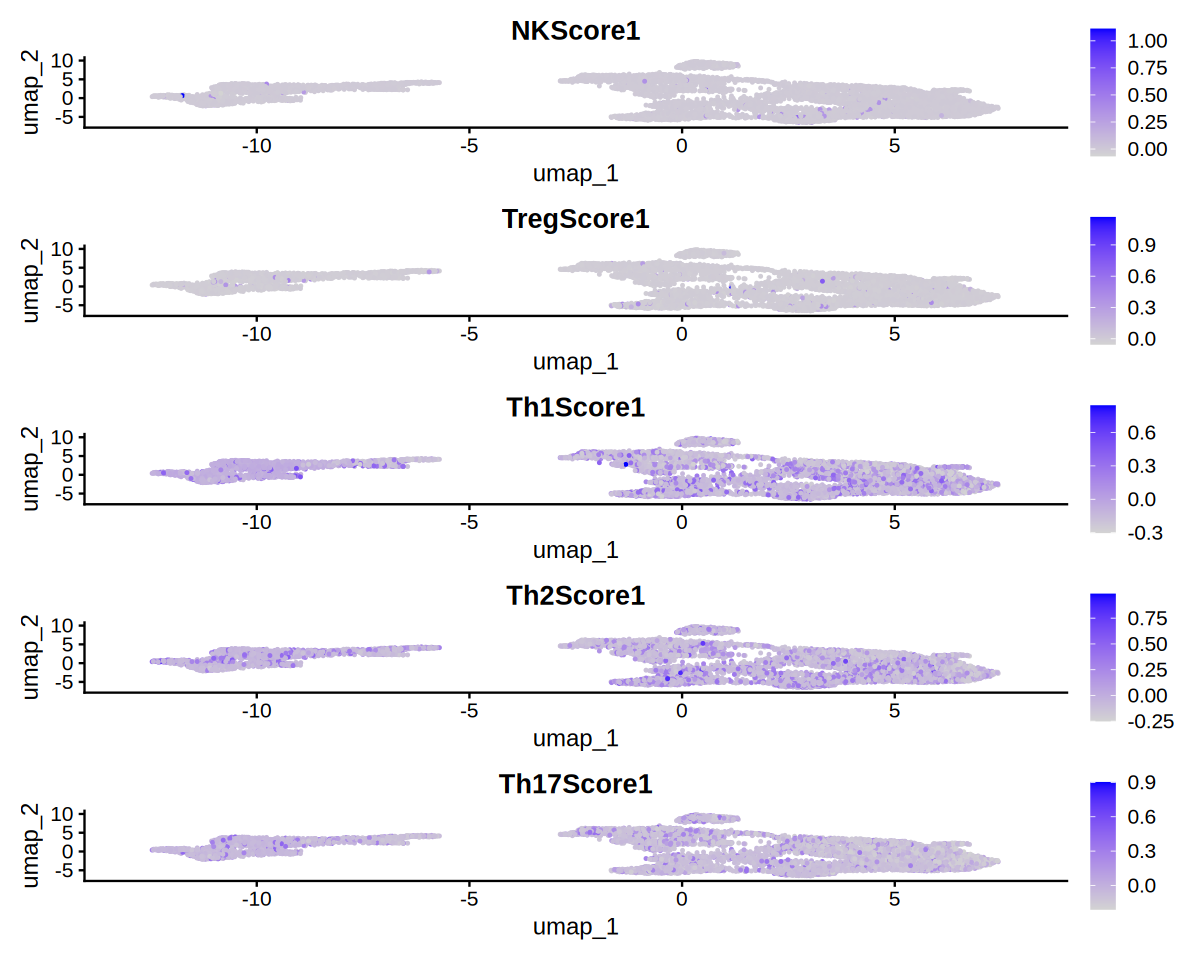

In [ ]:
FeaturePlot(global_obj, "NKScore1") +
FeaturePlot(global_obj, "TregScore1") +
FeaturePlot(global_obj, "Th1Score1") +
FeaturePlot(global_obj, "Th2Score1") +
FeaturePlot(global_obj, "Th17Score1")

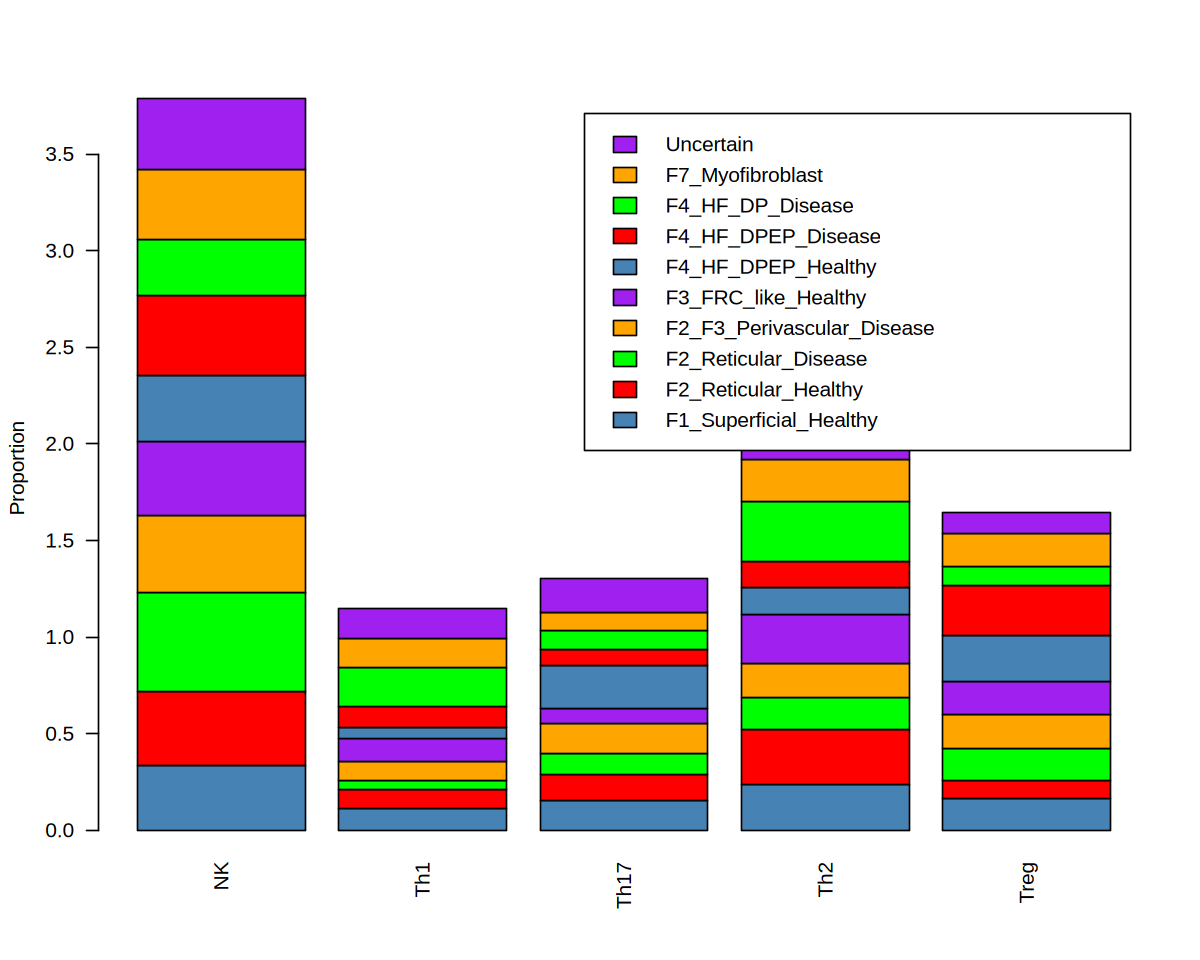

In [ ]:
global_obj$ImmuneType <- apply(
  global_obj@meta.data[, c(
    "NKScore1",
    "TregScore1",
    "Th1Score1",
    "Th2Score1",
    "Th17Score1"
  )],
  1,
  function(x) names(x)[which.max(x)]
)

global_obj$ImmuneType <- gsub("Score1", "", global_obj$ImmuneType)

prop.table <- table(global_obj$seurat_clusters, global_obj$ImmuneType)
prop.table <- prop.table / rowSums(prop.table)

barplot(prop.table,
        col = c("steelblue","red","green","orange","purple"),
        legend = TRUE,
        las = 2,
        ylab = "Proportion")

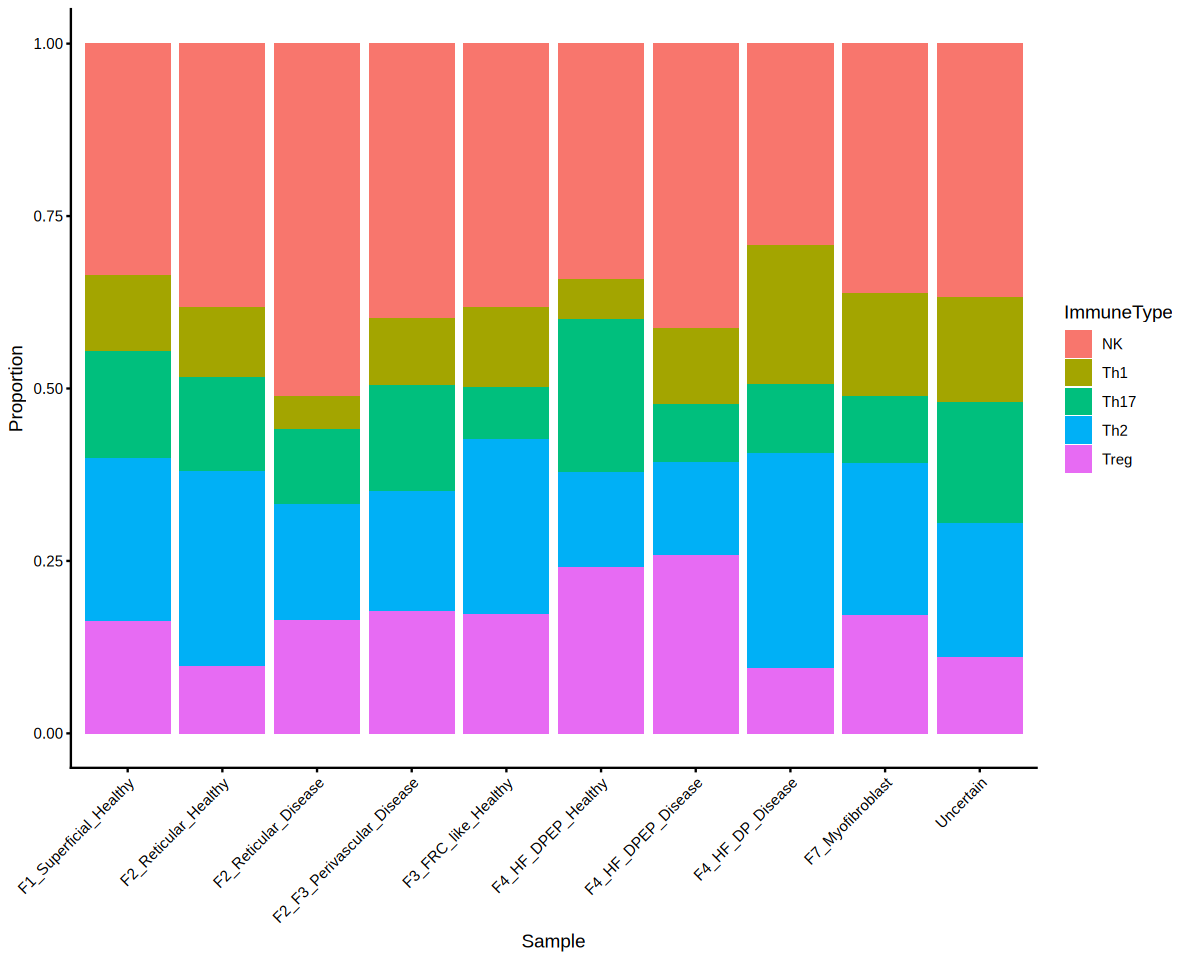

In [ ]:
prop.table2 <- table(global_obj$orig.ident2, global_obj$ImmuneType)
prop.table2 <- prop.table2 / rowSums(prop.table2)

df <- as.data.frame(prop.table2)
colnames(df) <- c("Sample", "ImmuneType", "Proportion")

ggplot(df, aes(x = Sample, y = Proportion, fill = ImmuneType)) +
  geom_bar(stat = "identity") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  ylab("Proportion") +
  xlab("Sample")

fibroblast subset

In [ ]:
sub_obj <- readRDS("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/processed/fibroblast_detailed_annotated.rds")
cell_count <- ncol(sub_obj)
message(sprintf("Current subset contains %d cells.", cell_count))

Current subset contains 8352 cells.



In [ ]:
colnames(sub_obj@meta.data)
table(sub_obj$orig.ident2)
table(sub_obj$Detailed_Condition)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_SCT"                        "nFeature_SCT"                     
 [7] "SCT_snn_res.0.8"                   "seurat_clusters"                  
 [9] "pANN_0.25_0.005_226"               "DF.classifications_0.25_0.005_226"
[11] "orig.ident1"                       "orig.ident2"                      
[13] "pANN_0.25_0.01_100"                "DF.classifications_0.25_0.01_100" 
[15] "pANN_0.25_0.005_591"               "DF.classifications_0.25_0.005_591"
[17] "pANN_0.25_0.005_182"               "DF.classifications_0.25_0.005_182"
[19] "pANN_0.25_0.23_208"                "DF.classifications_0.25_0.23_208" 
[21] "pANN_0.25_0.005_522"               "DF.classifications_0.25_0.005_522"
[23] "pANN_0.25_0.01_467"                "DF.classifications_0.25_0.01_467" 
[25] "S.Score"                           "G2M.Score"                        
[27] "Phase"                             "batch"                            
[29] "SCT_snn_res.0.05"                  "SCT_snn_res.0.1"                  
[31] "SCT_snn_res.0.2"                   "SCT_snn_res.0.3"                  
[33] "SCT_snn_res.0.4"                   "SCT_snn_res.0.6"                  
[35] "global_cluster"                    "SCT_snn_res.1"                    
[37] "SCT_snn_res.1.2"                   "Detailed_Condition"               
[39] "Condition"


  AC259   CH260  HTY131 HTY2901 HTY3080 HTY3106   UA258 
   2643    3461     299     120     158    1136     535 


  Acute Chronic Healthy 
   2643    3461    2248 

In [ ]:
# ==============================================================================
# 1. Define Gene Signatures
# ==============================================================================
# Note: Seurat's AddModuleScore requires the features to be formatted as a list.
mucin_sig <- list(c("HAS2", "HAS1", "HAS3", "VCAN", "FN1", "CEMIP", "HYAL1", "HYAL2", "CTGF", "TGFBI"))
fibro_sig <- list(c("COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL6A1", "FN1", "SPARC", "CTGF", "POSTN", "ACTA2", "TAGLN", "LOX", "LOXL2"))

# Safety Check: Ensure all genes actually exist in your dataset to prevent crashes
mucin_sig[[1]] <- intersect(mucin_sig[[1]], rownames(sub_obj))
fibro_sig[[1]] <- intersect(fibro_sig[[1]], rownames(sub_obj))

# ==============================================================================
# 2. Calculate Module Scores
# ==============================================================================
# Seurat automatically appends a "1" to the name you provide, 
# so the new metadata columns will be named "Mucin_Score1" and "Fibrosis_Score1"
sub_obj <- AddModuleScore(sub_obj, features = mucin_sig, name = "Mucin_Score")
sub_obj <- AddModuleScore(sub_obj, features = fibro_sig, name = "Fibrosis_Score")

# ==============================================================================
# 3. Project Scores onto Clusters
# ==============================================================================
# 3a. UMAP Spatial Distribution (FeaturePlot)
# Using 'blend = TRUE' allows you to see where the two signatures overlap in space
p_umap_scores <- FeaturePlot(sub_obj, 
                             features = c("Mucin_Score1", "Fibrosis_Score1"), 
                             blend = TRUE, 
                             pt.size = 0.8)
ggsave("UMAP_Mucin_vs_Fibrosis_Scores.pdf", p_umap_scores, width = 16, height = 6)

# 3b. Violin Plots (Identify which specific Detailed_Label scores the highest)
p_vln_scores <- VlnPlot(sub_obj, 
                        features = c("Mucin_Score1", "Fibrosis_Score1"), 
                        group.by = "Detailed_Label", 
                        pt.size = 0) + 
                theme(axis.text.x = element_text(angle = 45, hjust = 1))
ggsave("VlnPlot_Scores_by_Cluster.pdf", p_vln_scores, width = 14, height = 6)

# ==============================================================================
# 4. Compare Acute vs. Chronic Stages
# ==============================================================================
# Utilizing the "Detailed_Condition" column you created in your subset.R script.
# This will split the violin plots to show how the scores change over time within the same cell type.
p_acute_chronic <- VlnPlot(sub_obj, 
                           features = c("Mucin_Score1", "Fibrosis_Score1"), 
                           group.by = "Detailed_Label", 
                           split.by = "Detailed_Condition", 
                           pt.size = 0) +
                   theme(axis.text.x = element_text(angle = 45, hjust = 1))
ggsave("VlnPlot_Acute_vs_Chronic.pdf", p_acute_chronic, width = 16, height = 6)

# ==============================================================================
# 5. Mucin-high vs. Fibrosis-high Cell States (Scatter Plot)
# ==============================================================================
# This answers your question: "Are these different stromal states?"
p_scatter <- FeatureScatter(sub_obj, 
                            feature1 = "Mucin_Score1", 
                            feature2 = "Fibrosis_Score1", 
                            group.by = "Detailed_Label") +
             geom_vline(xintercept = 0, linetype = "dashed") + 
             geom_hline(yintercept = 0, linetype = "dashed") +
             ggtitle("Mucin vs Fibrosis Cell States")
ggsave("ScatterPlot_Mucin_vs_Fibrosis.pdf", p_scatter, width = 8, height = 6)

The default behaviour of split.by has changed.
Separate violin plots are now plotted side-by-side.
To restore the old behaviour of a single split violin,
set split.plot = TRUE.
      
This message will be shown once per session.

Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”


Macrophage

In [ ]:
mac_obj <- readRDS("/home/johan/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/macrophage/processed/macrophage_subset_processed.rds")
cell_count <- ncol(mac_obj)
message(sprintf("Current subset contains %d cells.", cell_count))

Current subset contains 1749 cells.



In [ ]:
biological_dictionary <- list(
  "F1_Superficial_Healthy" = c("APCDD1", "COL18A1", "COL23A1", "COL13A1", "COMP", "NKD2", "RSPO1", "AXIN2"),
  "F1_Superficial_Disease" = c("CRABP1", "CYP26B1", "TNFRSF21", "CXCL1", "WNT5A", "COL18A1", "COL23A1", "COL13A1", "NKD2", "AXIN2", "RSPO1"),
  "F2_Reticular_Healthy" = c("CD34", "PI16", "MFAP5", "DPP4", "PCOLCE2", "LGR5", "SLPI", "CD70", "CTHRC1"),
  "F2_Reticular_Disease" = c("PI16", "DPP4", "PCOLCE2", "MFAP5", "CD70", "LGR5"),
  "F2_F3_Perivascular_Healthy" = c("CXCL12", "APOE", "EFEMP1", "APOC1", "C7", "PLA2G2A", "PPARG", "MYOC", "GDF10"),
  "F2_F3_Perivascular_Disease" = c("CXCL12", "APOE", "C7", "PLA2G2A", "EFEMP1", "GDF10", "MYOC"),
  "F3_FRC_like_Healthy" = c("CCL19", "CD74", "CH25H", "TNFSF13B", "IL33", "IRF8", "IL15", "VCAM1", "HLA-DRB1", "HLA-DRA"),
  "F3_FRC_like_Disease" = c("CCL19", "CD74", "CH25H", "TNFSF13B", "IL33", "HLA-DRA", "IRF8", "COX4I2", "RBP5", "ADAMDEC1", "CXCL9", "CXCL10", "APOE", "CXCL12"),
  "F4_HF_DPEP_Healthy" = c("DPEP1", "MYL4", "MEF2C", "COL11A1"),
  "F4_HF_DPEP_Disease" = c("MEF2C", "MYL4", "COL11A1", "POSTN", "DPEP1"),
  "F4_HF_TNN_Healthy" = c("TNN", "COCH", "TNMD", "MKX", "NRG3", "SLITRK6"),
  "F4_HF_TNN_Disease" = c("COCH", "CRABP1", "COL24A1", "RSPO4", "SLITRK6", "NRG3", "MKX", "TNMD"),
  "F4_HF_DP_Healthy" = c("CORIN", "HHIP", "BMP7", "WNT5A", "LEF1"),
  "F4_HF_DP_Disease" = c("CRABP1", "COL24A1", "RSPO4", "RSPO3", "BMP7", "WNT5A", "LEF1", "SOX18", "HHIP"),
  "F5_Schwann_NGFR_Healthy" = c("NGFR", "ITGA6", "SCN7A", "CDH19", "CLDN1", "SFRP4", "TENM2"),
  "F5_Schwann_NGFR_Disease" = c("NGFR", "TM4SF1", "SFRP4", "ANGPTL7", "ITGA6", "CDH19", "CLDN1", "EBF2", "OLFM2", "SCN7A"),
  "F5_Schwann_RAMP1_Healthy" = c("RAMP1", "RELN", "PLEKHA6", "IGFBP2", "FGFBP2", "SCN7A"),
  "F5_Schwann_RAMP1_Disease" = c("RAMP1", "IGFBP2", "RELN", "COL26A1", "PLEKHA6", "FMO2", "FGFBP2"),
  "F6_Inflammatory_Myo_Disease" = c("IL11", "IL24", "CXCL5", "CXCL6", "CXCL8", "MMP9", "WNT2", "COL10A1", "MMP1", "MMP3"),
  "F7_Myofibroblast" = c("ACTA2", "TAGLN", "CTHRC1", "RUNX2", "KIF26B", "SULF1", "ADAM12", "COL8A1", "LRRC15", "CCN4", "ASPN", "POSTN", "TNC", "COL3A1", "WNT2", "COL10A1"),
  "F8_Fascia_like_Myo_Disease" = c("ACAN", "ITGA10", "CDH2", "DPP4", "CCN3"),
  "F_Fascia_Disease" = c("ITGA10", "CCN3", "DPP4", "CDH13", "PRG4", "CRTAC1", "PCOLCE2", "LGR5")
)

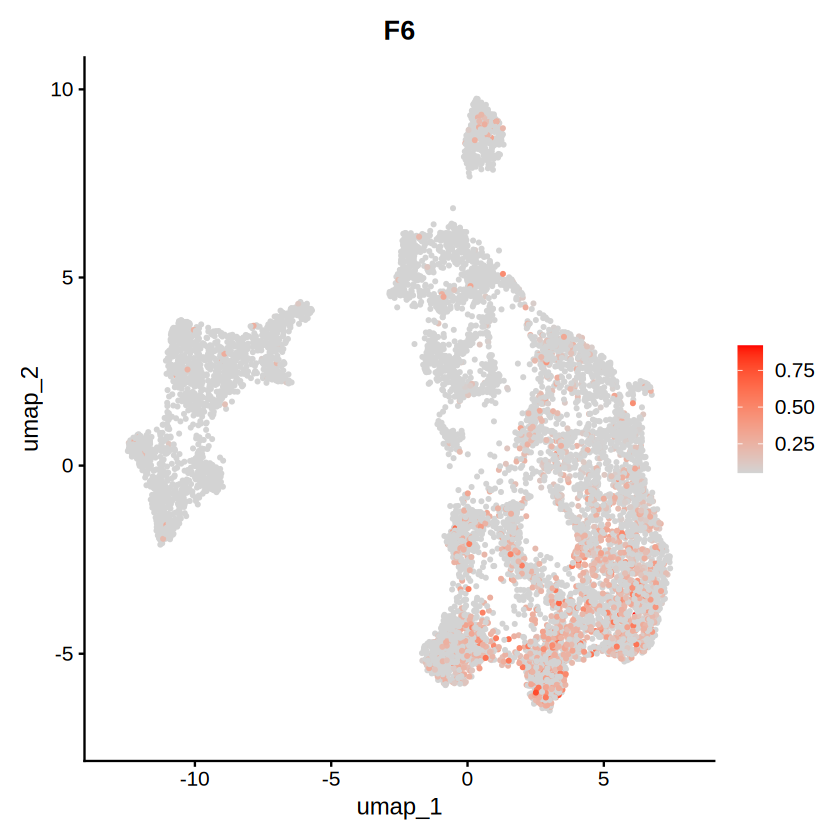

In [ ]:
# 1. Define the categories you want to look at
target_categories <- c(
  "F6_Inflammatory_Myo_Disease"
)

# 2. Extract and combine the unique genes from your dictionary
target_genes <- unique(unlist(biological_dictionary[target_categories]))

# 3. Filter for genes that are actually present in your Seurat object
# (Assuming your Seurat object is named 'seurat_obj')
valid_genes <- target_genes[target_genes %in% rownames(sub_obj)]

sub_obj <- AddModuleScore(
  object = sub_obj,
  features = list(valid_genes),
  name = "Myo_Fascia_Score"
)

# Note: Seurat automatically appends a '1' to the end of the name you provide
# 2. Plot the aggregated score
FeaturePlot(sub_obj, 
            features = "Myo_Fascia_Score1",
            cols = c("lightgrey", "red"), 
            min.cutoff = "q10",
            pt.size = 0.5) + 
  ggtitle("F6")

In [ ]:
mast_obj <- readRDS("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/mast_cell/processed/mast_cell_subset_processed.rds")
cell_count <- ncol(mast_obj)
message(sprintf("Current subset contains %d cells.", cell_count))

Current subset contains 366 cells.



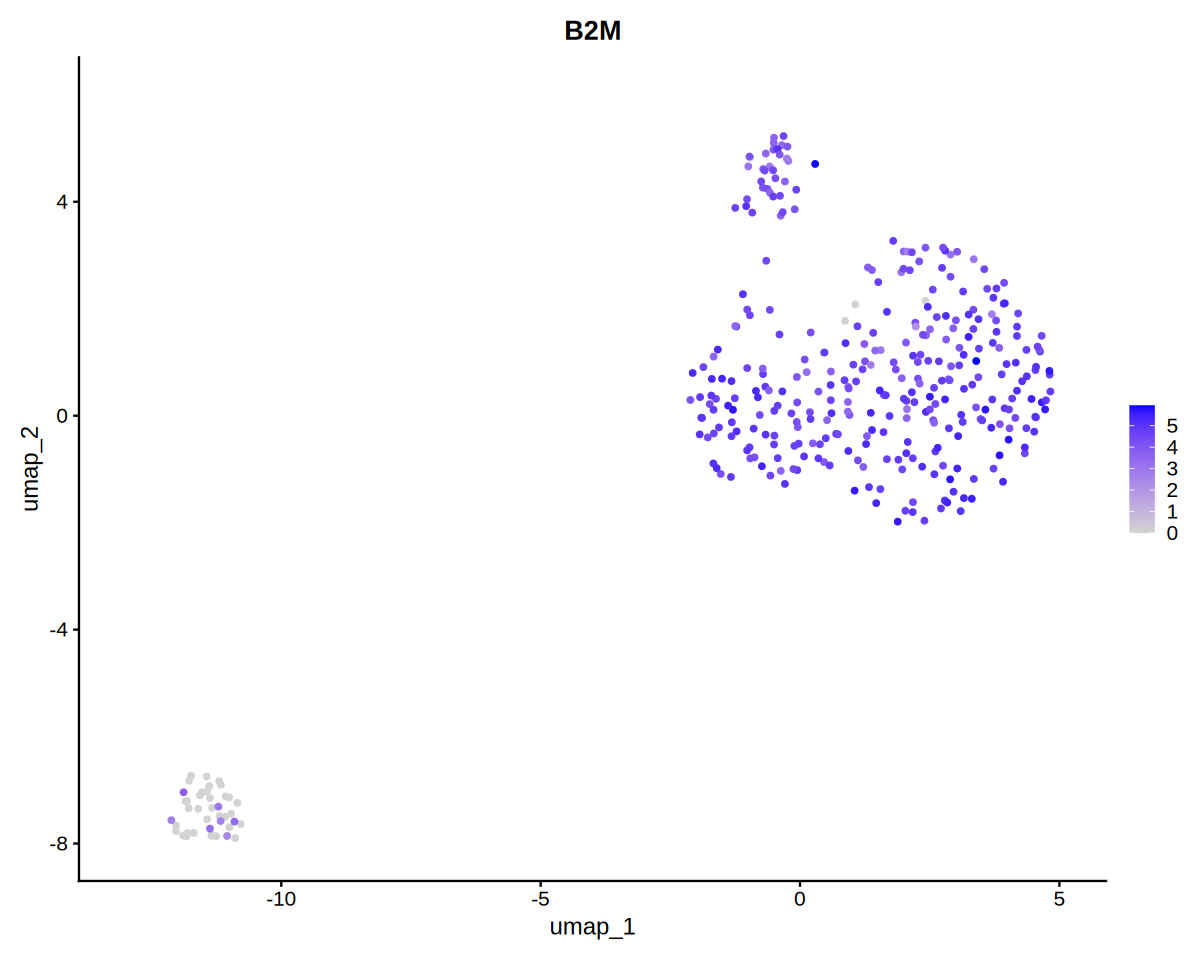

In [ ]:
FeaturePlot(mast_obj, c("B2M"))

In [ ]:
mast_dge <- read.csv("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/mast_cell/dge/mast_cell_markers.csv")
print(mast_dge)

           p_val avg_log2FC pct.1 pct.2    p_val_adj cluster       gene
1   2.892309e-34  2.6718913 0.997 0.447 6.687308e-30       0      TPSB2
2   7.272664e-30  2.9561058 0.962 0.276 1.681513e-25       0     TPSAB1
3   5.119449e-26  2.0560301 0.983 0.408 1.183668e-21       0       PTMA
4   3.818388e-25  1.9096455 0.986 0.539 8.828496e-21       0        B2M
5   5.842393e-25  2.2796584 0.948 0.408 1.350820e-20       0     S100A4
6   1.194413e-23  1.7647250 0.979 0.434 2.761601e-19       0      RPL41
7   6.350043e-23  1.9222807 0.969 0.395 1.468194e-18       0      RPL10
8   1.296481e-22  2.1107981 0.941 0.342 2.997593e-18       0      RPL32
9   4.662965e-22  1.8524696 1.000 0.605 1.078124e-17       0       FTH1
10  1.112027e-21  2.3425418 0.921 0.368 2.571117e-17       0   HSP90AA1
11  3.368421e-21  2.8523516 0.831 0.237 7.788127e-17       0        UBB
12  4.893563e-21  2.5578242 0.869 0.342 1.131441e-16       0       JUNB
13  6.405326e-21  2.0163052 0.914 0.368 1.480975e-16       0    